# Salary Range Prediction
## End-to-End Machine Learning Pipeline

##  Project Overview

This project focuses on predicting salary ranges (minimum and maximum) for job postings using machine learning techniques.  
The goal is to build an end-to-end pipeline that includes data preprocessing, feature engineering, model training, and evaluation.

The model helps:
- Estimate fair salary ranges  
- Improve hiring decisions  
- Provide transparency in job postings

# Importing Libraries

All required libraries for data processing, visualization, and model building are imported.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.model_selection import cross_val_score
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Data Loading
df = pd.read_csv("Jobs_NYC_Postings.csv")

In [3]:
pd.set_option('display.max_columns',None)
df.head()

,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Title Code No,Level,Job Category,Full-Time/Part-Time indicator,Career Level,Salary Range From,Salary Range To,Salary Frequency,Work Location,Division/Work Unit,Job Description,Minimum Qual Requirements,Preferred Skills,Additional Information,To Apply,Hours/Shift,Work Location 1,Recruitment Contact,Residency Requirement,Posting Date,Post Until,Posting Updated,Process Date
0,623668,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Research Analyst, IMAT, Bureau of Maternal Inf...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,02,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),82506.0,94882.0,Annual,42-09 28th Street,"Maternal, Infant, & Repr. Hlth","Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",Experience in quantitative research methods an...,**IMPORTANT NOTES TO ALL CANDIDATES: Please n...,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,01/23/2024,22-MAY-2024,01/23/2024,03/04/2024
1,608193,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Deputy Director,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Policy, Research & Analysis Public Safety, Ins...",F,Experienced (non-manager),58682.0,134570.0,Annual,30-30 Thomson Ave L I City Qns,Pub Bldgs/Transportation,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates must have excellent management skil...,Authorization to work in the United States is ...,"For City Employees, please go to Employee Self...",35 Hours,"30-30 Thomson Avenue, LIC, NY 11101",NaN,New York City Residency is not required for th...,10/03/2023,NaN,11/29/2023,03/04/2024
2,625094,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Senior Project Manager,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Engineering, Architecture, & Planning",F,Experienced (non-manager),58682.0,91405.0,Annual,30-30 Thomson Ave L I City Qns,PUB BLDGS/CPD/Library/Brooklyn,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates should have at least six years of e...,NaN,NaN,NaN,NaN,NaN,New York City Residency is not required for th...,02/01/2024,NaN,02/01/2024,03/04/2024
3,580593,DEPARTMENT OF TRANSPORTATION,External,1,Procurement Analyst 2,PROCUREMENT ANALYST,Competitive-1,12158,02,"Finance, Accounting, & Procurement",F,Experienced (non-manager),50972.0,82730.0,Annual,55 Water St Ny Ny,Bridge Repair/352 Kent St,Reporting directly to the Director of Bridge R...,1. A baccalaureate degree from an accredited c...,Familiar with and knowledge of Procurement sys...,The City of New York is an inclusive equal opp...,Resumes may be submitted electronically using ...,9:00am â 5:00pm,To be determine.,NaN,New York City residency is generally required ...,04/04/2023,NaN,04/04/2023,03/04/2024
4,624937,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Deputy Director, HIV Planning Council, Divisio...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,03,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),92301.0,106146.0,Annual,42-09 28th Street,Dis-Div. Mgmt. & Sys Coord,"Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",At least five yearsâ work experience in the ...,NaN,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,02/06/2024,05-JUN-2024,02/21/2024,03/04/2024


## Data Overview

Basic information such as number of rows, columns, and data types is examined.

In [4]:
df.shape

(5120, 30)

In [5]:
print(list(df.columns))

['Job ID', 'Agency', 'Posting Type', '# Of Positions', 'Business Title', 'Civil Service Title', 'Title Classification', 'Title Code No', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Career Level', 'Salary Range From', 'Salary Range To', 'Salary Frequency', 'Work Location', 'Division/Work Unit', 'Job Description', 'Minimum Qual Requirements', 'Preferred Skills', 'Additional Information', 'To Apply', 'Hours/Shift', 'Work Location 1', 'Recruitment Contact', 'Residency Requirement', 'Posting Date', 'Post Until', 'Posting Updated', 'Process Date']


In [6]:
df.nunique()

Job ID                           2626
Agency                             59
Posting Type                        2
# Of Positions                     35
Business Title                   1781
Civil Service Title               365
Title Classification                5
Title Code No                     388
Level                              18
Job Category                      183
Full-Time/Part-Time indicator       2
Career Level                        5
Salary Range From                 559
Salary Range To                   748
Salary Frequency                    3
Work Location                     293
Division/Work Unit                852
Job Description                  2518
Minimum Qual Requirements         445
Preferred Skills                 1639
Additional Information            780
To Apply                         1332
Hours/Shift                       315
Work Location 1                   268
Recruitment Contact                 0
Residency Requirement              80
Posting Date

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Job ID                         5120 non-null   int64  
 1   Agency                         5120 non-null   object 
 2   Posting Type                   5120 non-null   object 
 3   # Of Positions                 5120 non-null   int64  
 4   Business Title                 5120 non-null   object 
 5   Civil Service Title            5120 non-null   object 
 6   Title Classification           5120 non-null   object 
 7   Title Code No                  5120 non-null   object 
 8   Level                          5120 non-null   object 
 9   Job Category                   5120 non-null   object 
 10  Full-Time/Part-Time indicator  5003 non-null   object 
 11  Career Level                   5120 non-null   object 
 12  Salary Range From              5120 non-null   f

## Feature Engineering

Average salary is calculated using Salary Range From and Salary Range To .

In [8]:
df['Average_Salary'] = (df['Salary Range From'] + df['Salary Range To']) / 2

In [9]:
df['Average_Salary'].mean()

np.float64(77301.89992847657)

In [10]:
df.head()

,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Title Code No,Level,Job Category,Full-Time/Part-Time indicator,Career Level,Salary Range From,Salary Range To,Salary Frequency,Work Location,Division/Work Unit,Job Description,Minimum Qual Requirements,Preferred Skills,Additional Information,To Apply,Hours/Shift,Work Location 1,Recruitment Contact,Residency Requirement,Posting Date,Post Until,Posting Updated,Process Date,Average_Salary
0,623668,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Research Analyst, IMAT, Bureau of Maternal Inf...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,02,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),82506.0,94882.0,Annual,42-09 28th Street,"Maternal, Infant, & Repr. Hlth","Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",Experience in quantitative research methods an...,**IMPORTANT NOTES TO ALL CANDIDATES: Please n...,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,01/23/2024,22-MAY-2024,01/23/2024,03/04/2024,88694.0
1,608193,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Deputy Director,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Policy, Research & Analysis Public Safety, Ins...",F,Experienced (non-manager),58682.0,134570.0,Annual,30-30 Thomson Ave L I City Qns,Pub Bldgs/Transportation,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates must have excellent management skil...,Authorization to work in the United States is ...,"For City Employees, please go to Employee Self...",35 Hours,"30-30 Thomson Avenue, LIC, NY 11101",NaN,New York City Residency is not required for th...,10/03/2023,NaN,11/29/2023,03/04/2024,96626.0
2,625094,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Senior Project Manager,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Engineering, Architecture, & Planning",F,Experienced (non-manager),58682.0,91405.0,Annual,30-30 Thomson Ave L I City Qns,PUB BLDGS/CPD/Library/Brooklyn,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates should have at least six years of e...,NaN,NaN,NaN,NaN,NaN,New York City Residency is not required for th...,02/01/2024,NaN,02/01/2024,03/04/2024,75043.5
3,580593,DEPARTMENT OF TRANSPORTATION,External,1,Procurement Analyst 2,PROCUREMENT ANALYST,Competitive-1,12158,02,"Finance, Accounting, & Procurement",F,Experienced (non-manager),50972.0,82730.0,Annual,55 Water St Ny Ny,Bridge Repair/352 Kent St,Reporting directly to the Director of Bridge R...,1. A baccalaureate degree from an accredited c...,Familiar with and knowledge of Procurement sys...,The City of New York is an inclusive equal opp...,Resumes may be submitted electronically using ...,9:00am â 5:00pm,To be determine.,NaN,New York City residency is generally required ...,04/04/2023,NaN,04/04/2023,03/04/2024,66851.0
4,624937,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Deputy Director, HIV Planning Council, Divisio...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,03,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),92301.0,106146.0,Annual,42-09 28th Street,Dis-Div. Mgmt. & Sys Coord,"Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",At least five yearsâ work experience in the ...,NaN,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,02/06/2024,05-JUN-2024,02/21/2024,03/04/2024,99223.5


## Statistical Summary

Basic statistical information is analyzed to understand salary distribution and numeric features.

In [11]:
df.describe()

,Job ID,# Of Positions,Salary Range From,Salary Range To,Recruitment Contact,Average_Salary
count,5120.000000,5120.000000,5120.000000,5120.000000,0.0,5120.000000
mean,598721.366211,2.070898,64625.224123,89978.575734,NaN,77301.899928
std,28274.636161,5.799227,31378.516179,46732.299939,NaN,36748.806003
min,469953.000000,1.000000,0.000000,15.000000,NaN,15.000000
25%,586358.000000,1.000000,51869.000000,64608.000000,NaN,58405.000000
50%,607060.000000,1.000000,62397.000000,85147.000000,NaN,75745.500000
75%,621404.000000,1.000000,80557.000000,113550.000000,NaN,98571.000000
max,628806.000000,150.000000,225000.000000,252165.000000,NaN,235500.000000


## Missing Values Analysis

Identifying missing values in the dataset to handle them appropriately.

In [12]:
df.isnull().sum()

Job ID                              0
Agency                              0
Posting Type                        0
# Of Positions                      0
Business Title                      0
Civil Service Title                 0
Title Classification                0
Title Code No                       0
Level                               0
Job Category                        0
Full-Time/Part-Time indicator     117
Career Level                        0
Salary Range From                   0
Salary Range To                     0
Salary Frequency                    0
Work Location                       0
Division/Work Unit                  0
Job Description                     0
Minimum Qual Requirements          43
Preferred Skills                 1219
Additional Information           1862
To Apply                          426
Hours/Shift                      3210
Work Location 1                  3229
Recruitment Contact              5120
Residency Requirement               0
Posting Date

## Removing Irrelevant Columns

Unnecessary columns are removed to simplify the dataset and improve model performance.

In [13]:
drop_cols = [
    'Job ID', 'Title Code No', 'Process Date', 'Posting Updated', 'Post Until',
    'Recruitment Contact', 'To Apply', 'Additional Information', 'Division/Work Unit'
]


In [14]:
df = df.drop(columns=drop_cols)

In [15]:
df.isnull().sum()

Agency                              0
Posting Type                        0
# Of Positions                      0
Business Title                      0
Civil Service Title                 0
Title Classification                0
Level                               0
Job Category                        0
Full-Time/Part-Time indicator     117
Career Level                        0
Salary Range From                   0
Salary Range To                     0
Salary Frequency                    0
Work Location                       0
Job Description                     0
Minimum Qual Requirements          43
Preferred Skills                 1219
Hours/Shift                      3210
Work Location 1                  3229
Residency Requirement               0
Posting Date                        0
Average_Salary                      0
dtype: int64

In [16]:
df.drop(columns=[ 'Hours/Shift', 'Work Location 1'], inplace=True)

## Handling Missing Values

Missing values are filled using appropriate techniques such as mode and empty strings.

In [17]:
df['Preferred Skills'] = df['Preferred Skills'].fillna('')
df['Minimum Qual Requirements'] = df['Minimum Qual Requirements'].fillna('')

In [18]:
mode_val = df['Full-Time/Part-Time indicator'].mode()[0]

df['Full-Time/Part-Time indicator'] = df['Full-Time/Part-Time indicator'].fillna(mode_val)

## Removing Duplicates

Duplicate records are removed to ensure data quality and avoid bias in the model.

In [19]:
df.duplicated().sum()

np.int64(31)

In [20]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (5120, 20)
After: (5089, 20)


 A small number of duplicate rows were found and removed from the dataset.

## Exploratory Data Analysis

Visualizing salary Range distribution and understanding key patterns in the dataset.

### SALARY DISTRIBUTION GRAPH 
The distribution of average salary is analyzed to understand skewness and spread of salary values.

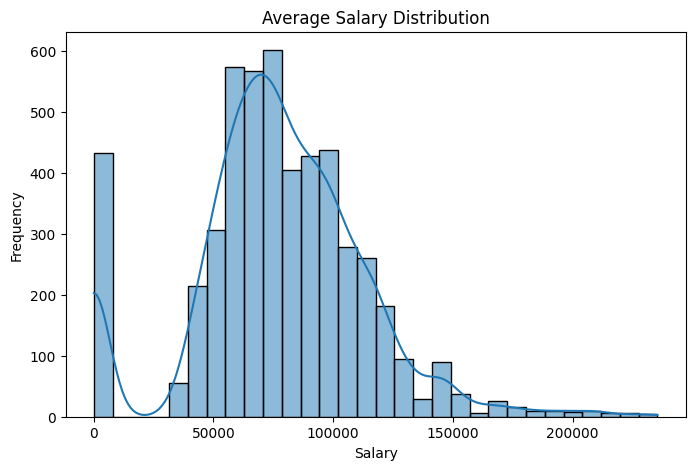

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Average_Salary'], bins=30, kde=True)
plt.title("Average Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

### TOP JOB CATEGORIES
Top job categories are analyzed to identify the most frequent roles in the dataset.

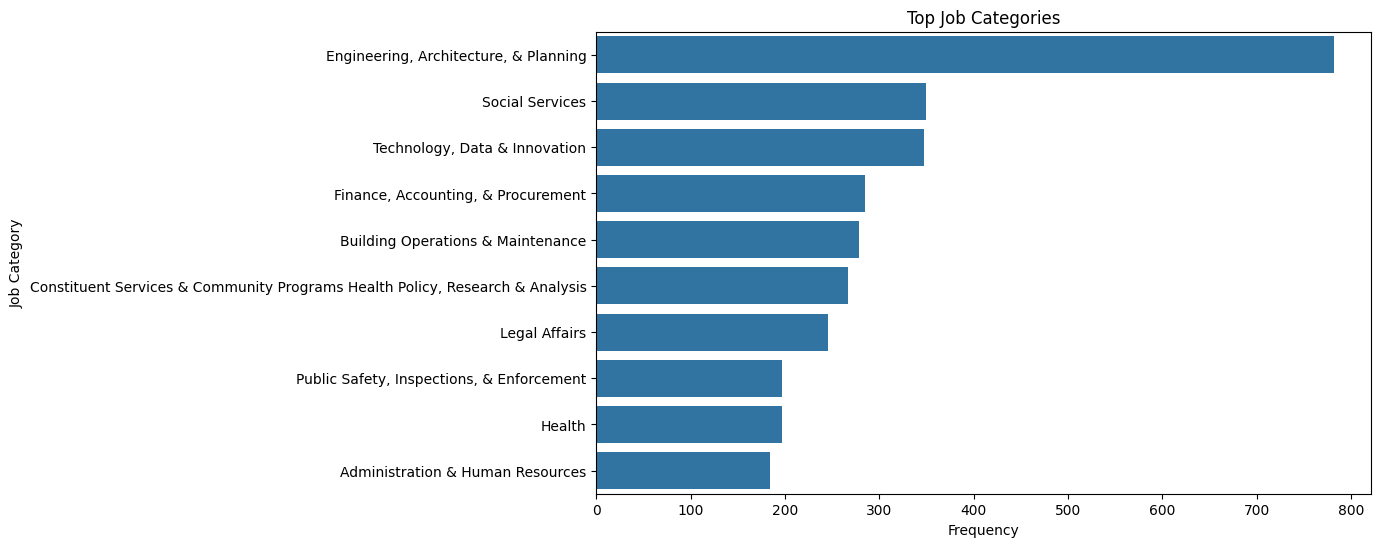

In [22]:
top_categories = df['Job Category'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title("Top Job Categories")
plt.xlabel("Frequency")
plt.ylabel("Job Category")
plt.show()

### POSTING TYPE Distribution 
Distribution of internal and external job postings is examined.

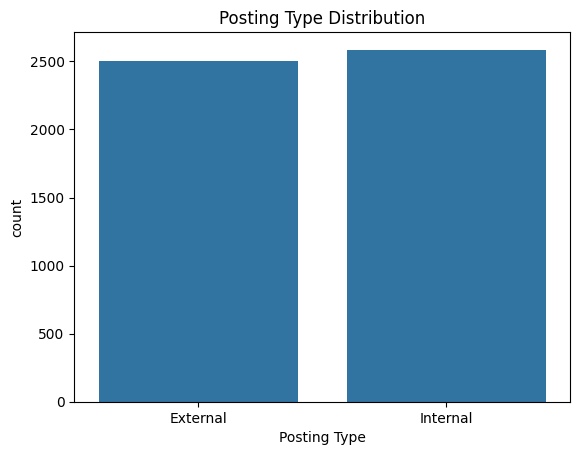

In [23]:
sns.countplot(x='Posting Type', data=df)
plt.title("Posting Type Distribution")
plt.show()

### CAREER LEVEL VS SALARY
Salary variation across different career levels is analyzed.

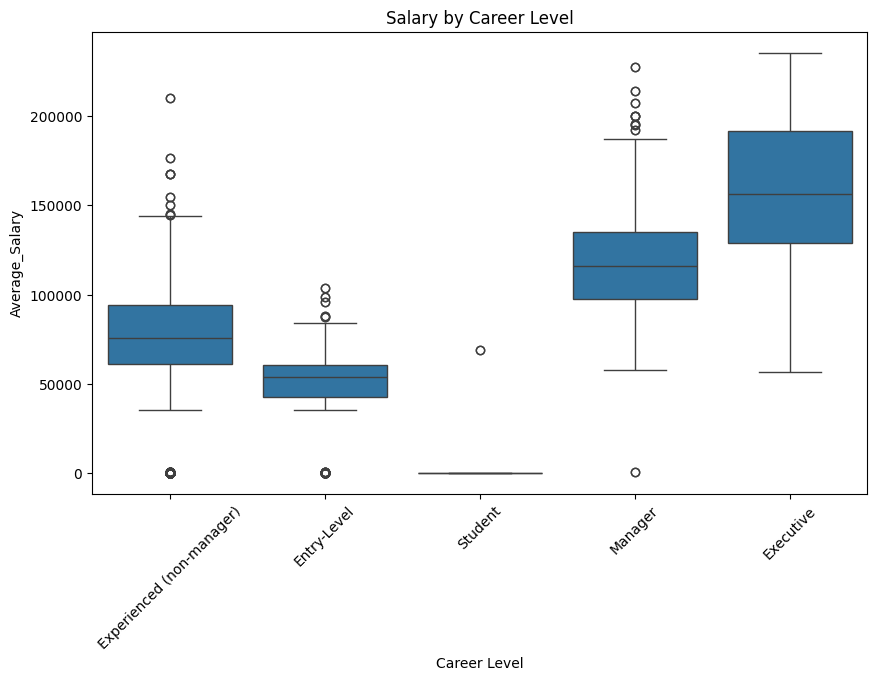

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Career Level', y='Average_Salary', data=df)
plt.title("Salary by Career Level")
plt.xticks(rotation=45)
plt.show()

### FULL-TIME VS PART-TIME
Comparison of salary based on employment type (full-time vs part-time).

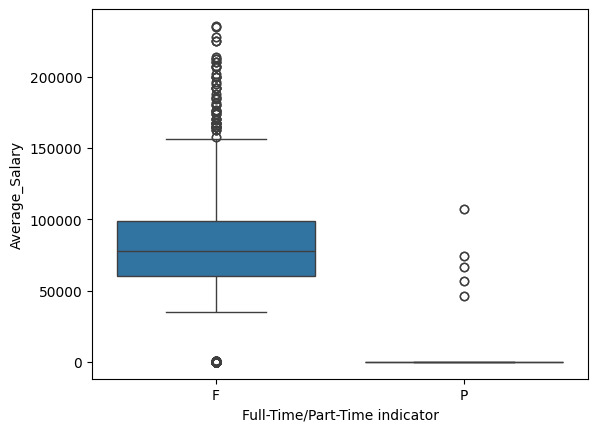

In [25]:
sns.boxplot(x='Full-Time/Part-Time indicator', y='Average_Salary', data=df)
plt.show()

### SALARY OVER TIME
Trend of average salary over the years is analyzed.

In [26]:
df['Posting Date'] = pd.to_datetime(df['Posting Date'], errors='coerce')

df['Year'] = df['Posting Date'].dt.year

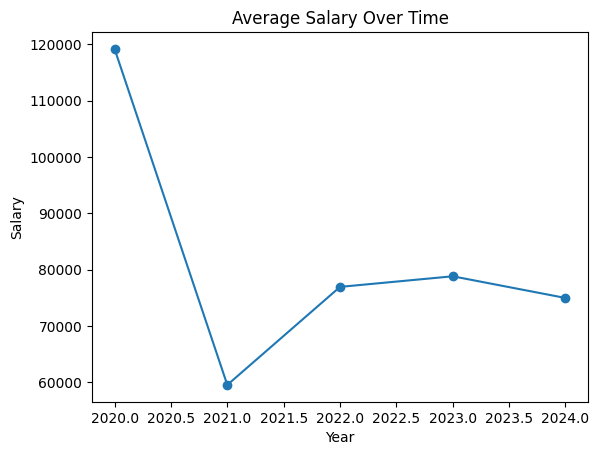

In [27]:
salary_by_year = df.groupby('Year')['Average_Salary'].mean()
salary_by_year.plot(kind='line', title='Average Salary Over Time', marker='o')
plt.ylabel("Salary")
plt.show()

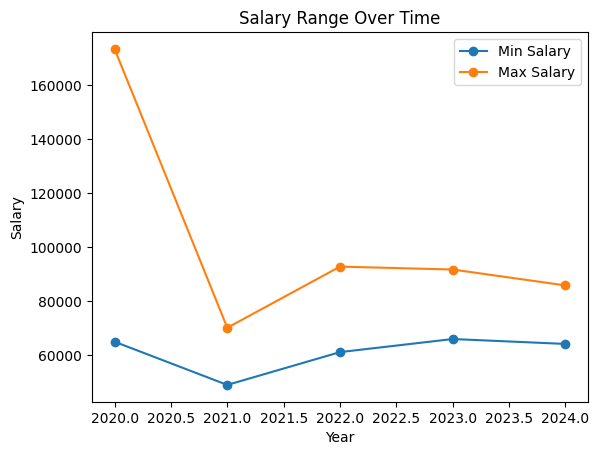

In [28]:
min_salary = df.groupby('Year')['Salary Range From'].mean()
max_salary = df.groupby('Year')['Salary Range To'].mean()

plt.figure()
plt.plot(min_salary, label='Min Salary', marker='o')
plt.plot(max_salary, label='Max Salary', marker='o')

plt.title("Salary Range Over Time")
plt.xlabel("Year")
plt.ylabel("Salary")
plt.legend()
plt.show()

### Top Highest paying job Titles
Top highest paying job titles are identified.

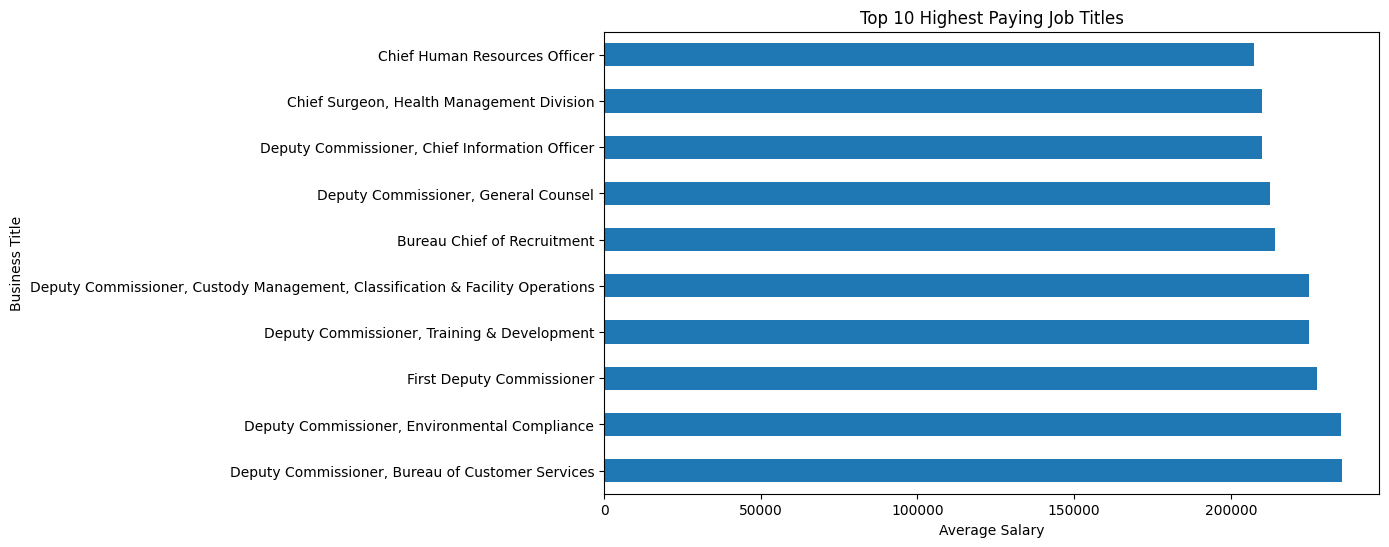

In [29]:
top_jobs = df.groupby('Business Title')['Average_Salary'].mean().sort_values(ascending=False).head(10)

top_jobs.plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Highest Paying Job Titles")
plt.xlabel("Average Salary")
plt.show()

### TOP AGENCIES
Agencies offering higher average salaries are analyzed.

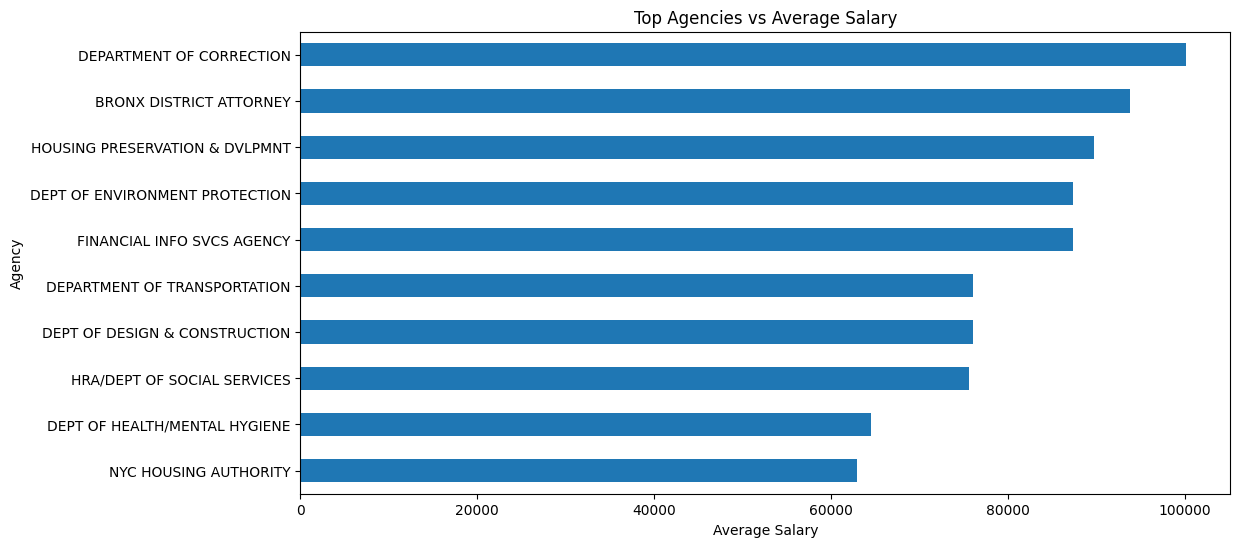

In [30]:
top_agency = df['Agency'].value_counts().head(10).index

agency_salary = df[df['Agency'].isin(top_agency)] \
    .groupby('Agency')['Average_Salary'].mean() \
    .sort_values()

plt.figure(figsize=(12,6))
agency_salary.plot(kind='barh')

plt.title("Top Agencies vs Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("Agency")
plt.show()

## Outlier Analysis

Boxplots are used to identify extreme values in salary-related features.

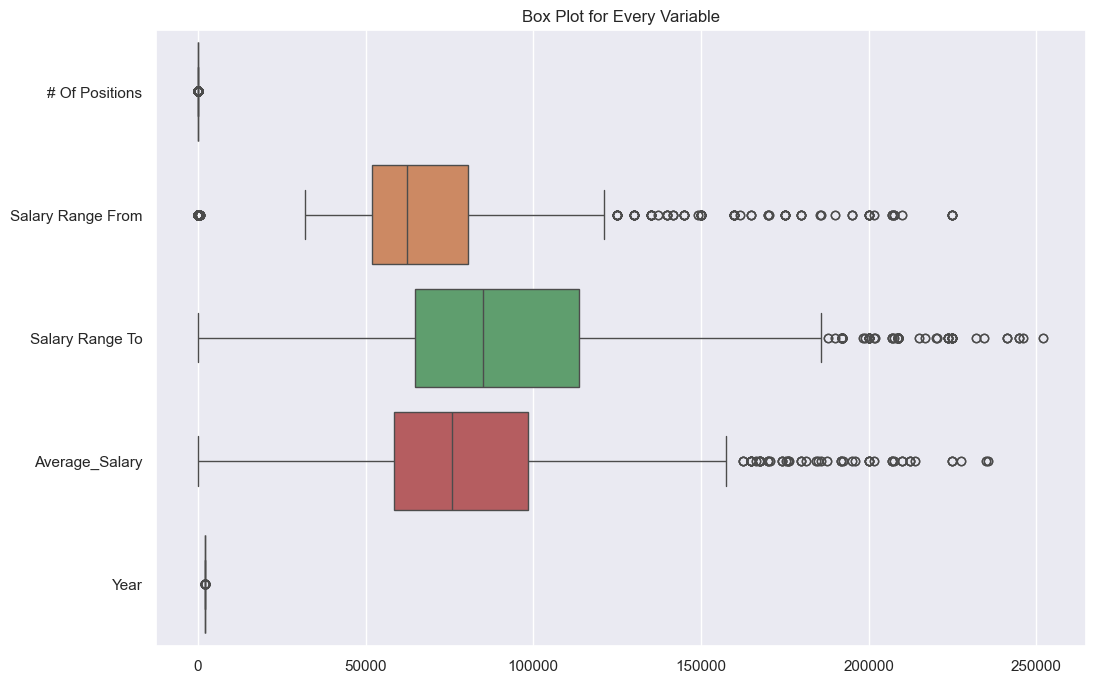

(5089, 21)


In [31]:
plt.figure(figsize=(12, 8))
sns.set(style="darkgrid")
sns.boxplot(data=df, orient="h")
plt.title("Box Plot for Every Variable")
plt.show()
print(df.shape)

In [32]:
## OUTLIER HANDLING USING IOR METHOD
outliers_cols = ["Average_Salary", "Salary Range From", "Salary Range To"]

for column in outliers_cols:
    if df[column].dtype in ["float64", "int64"]:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        df[column] = df[column].clip(lower_bound, upper_bound)

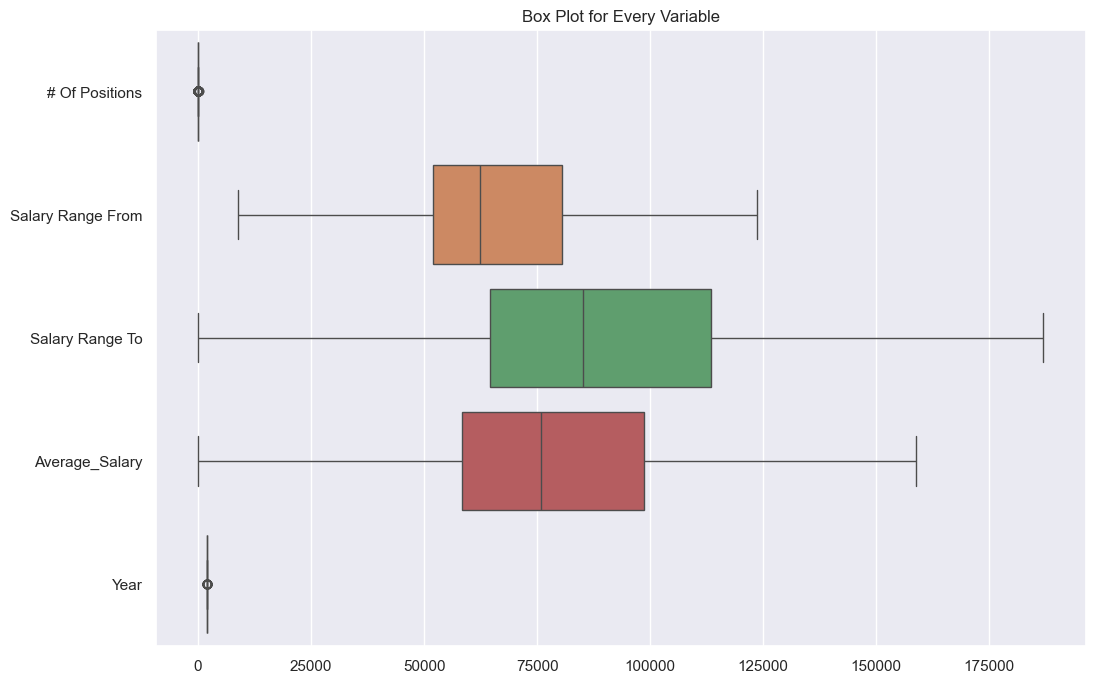

(5089, 21)


In [33]:
plt.figure(figsize=(12, 8))
sns.set(style="darkgrid")
booking_boxplot = sns.boxplot(data=df, orient="h")
plt.title("Box Plot for Every Variable")
plt.show()
print(df.shape)

In [34]:
df['combined_text']=(
 df['Preferred Skills'].astype(str)
 + ' ' +
 df['Minimum Qual Requirements'].astype(str)
)

In [35]:
tfidf=TfidfVectorizer(
 max_features=300,
 stop_words='english'
)

text_features=tfidf.fit_transform(
 df['combined_text']
)

## Encoding Categorical Variables

Categorical features are converted into numerical form using Label Encoding.

In [36]:
## LABEL ENCODING 
df_encoded = df.copy()
label_cols = df_encoded.select_dtypes(include='object').columns

for col in label_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

## Feature Correlation

Correlation heatmap is used to identify relationships between features and salary.

<Axes: >

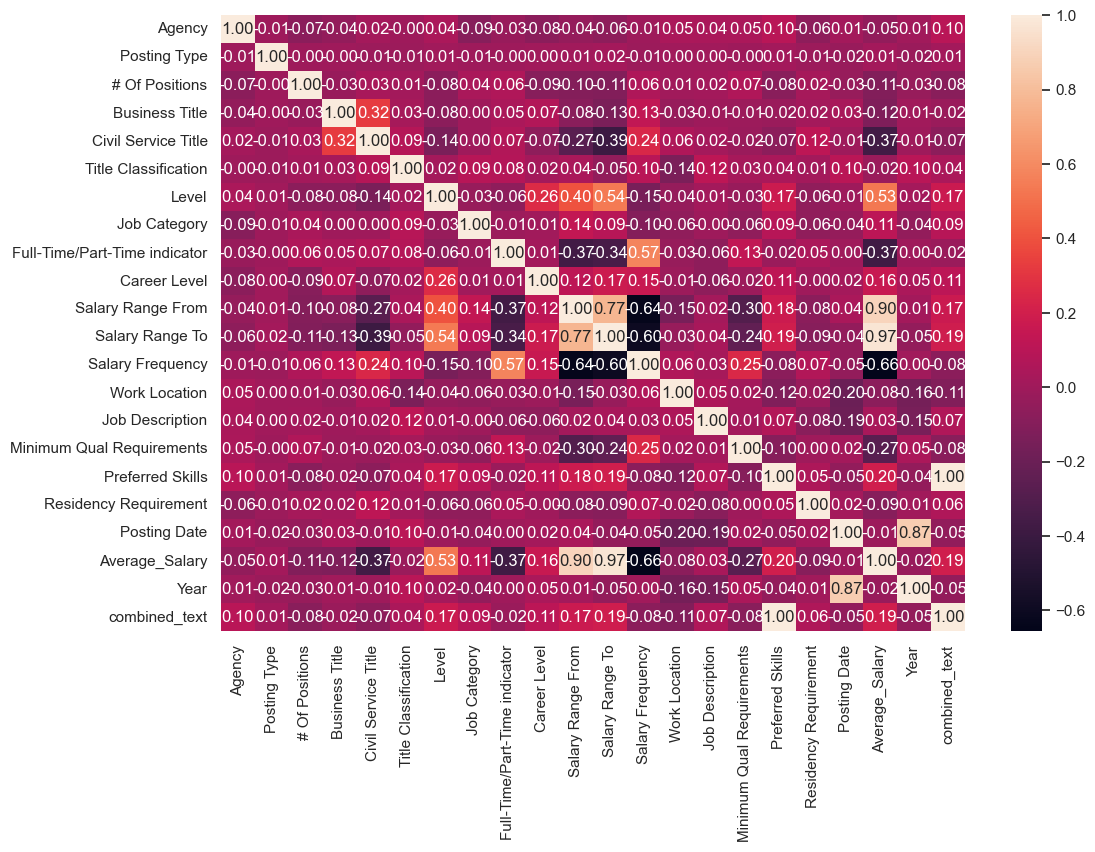

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr() , annot=True ,fmt='.2f')

In [38]:
print(df_encoded.dtypes)

Agency                                    int64
Posting Type                              int64
# Of Positions                            int64
Business Title                            int64
Civil Service Title                       int64
Title Classification                      int64
Level                                     int64
Job Category                              int64
Full-Time/Part-Time indicator             int64
Career Level                              int64
Salary Range From                       float64
Salary Range To                         float64
Salary Frequency                          int64
Work Location                             int64
Job Description                           int64
Minimum Qual Requirements                 int64
Preferred Skills                          int64
Residency Requirement                     int64
Posting Date                     datetime64[ns]
Average_Salary                          float64
Year                                    

## Model Building

The dataset is split into features (X) and target variable (Average Salary).

In [39]:
df_encoded.drop(columns=['Posting Date'], inplace=True)

In [40]:
X = df_encoded.drop(columns=[
    'Average_Salary',
    'Salary Range From',
    'Salary Range To'
])
y = df_encoded['Average_Salary']

###### The data is divided into training and testing sets (80-20 split) to evaluate model performance.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Salary Range Modeling

Separate models are prepared to predict minimum and maximum salary.

In [42]:
y_min = df_encoded['Salary Range From']
y_max = df_encoded['Salary Range To']

In [43]:
X_range = df_encoded.drop(columns=['Salary Range From', 'Salary Range To', 'Average_Salary'])

In [44]:
X_train_r, X_test_r, y_min_train, y_min_test, y_max_train, y_max_test = train_test_split(
    X_range, y_min, y_max, test_size=0.2, random_state=42
)

In [45]:
## A custom evaluation function is created to calculate MAE, RMSE, and R2 score.
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [46]:
## Multiple regression models are used to compare performance and identify the best model.
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1),
    "AdaBoost": AdaBoostRegressor()
}

In [47]:
## Each model is trained and evaluated on both training and testing datasets.
model_names = []
r2_scores = []
for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)
    
    # Print Output (same as your format)
    print(name)
    
    print("Model performance for Training set")
    print("- Root Mean Squared Error: {:.4f}".format(train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(train_mae))
    print("- R2 Score: {:.4f}".format(train_r2))
    
    print('----------------------------------')
    
    print("Model performance for Test set")
    print("- Root Mean Squared Error: {:.4f}".format(test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(test_mae))
    print("- R2 Score: {:.4f}".format(test_r2))
    
    print("="*35)
    print("\n")
    model_names.append(name)
    r2_scores.append(test_r2)

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 19596.7646
- Mean Absolute Error: 15084.2184
- R2 Score: 0.6853
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 18789.3590
- Mean Absolute Error: 14473.0454
- R2 Score: 0.7215


Lasso
Model performance for Training set
- Root Mean Squared Error: 19596.7660
- Mean Absolute Error: 15084.1904
- R2 Score: 0.6853
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 18789.0133
- Mean Absolute Error: 14472.7638
- R2 Score: 0.7215


Ridge
Model performance for Training set
- Root Mean Squared Error: 19596.7745
- Mean Absolute Error: 15083.3290
- R2 Score: 0.6853
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 18788.2276
- Mean Absolute Error: 14471.0622
- R2 Score: 0.7215


KNN
Model performance for Training set
- Root Mean Squared Error: 20317.3353
- Mean Absolute Error: 13630.2179
- R2

#### INSIGHT 
XGBoost, KNN, and Random Forest show the highest performance based on R2 score.

In [48]:
results_df = pd.DataFrame({
    "Model Name": model_names,
    "R2_Score": r2_scores
})

results_df = results_df.sort_values(by="R2_Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)

results_df

,Model Name,R2_Score
0,Random Forest,0.970229
1,XGBoost,0.969703
2,Decision Tree,0.962923
3,AdaBoost,0.743755
4,Ridge,0.721525
5,Lasso,0.721501
6,Linear Regression,0.721491
7,KNN,0.441692


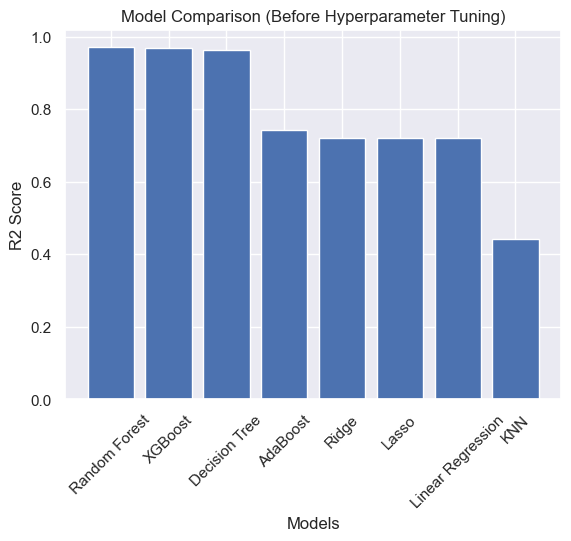

In [49]:
## A visual comparison of model performance before hyperparameter tuning.
plt.figure()

plt.bar(results_df["Model Name"], results_df["R2_Score"])

plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (Before Hyperparameter Tuning)")

plt.show()

## Hyperparameter Tuning

RandomizedSearchCV is used to find the best parameters for selected models.

In [50]:
knn_params = {
    "n_neighbors": [2, 3, 10, 20, 40, 50]
}

# Random Forest
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

# XGBoost
xgb_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 6, 8],
    "n_estimators": [100, 200, 300],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [51]:
randomcv_models = [('KNN', KNeighborsRegressor(), knn_params),
                   ("RF", RandomForestRegressor(), rf_params),
                   ('XGBoost', XGBRegressor(), xgb_params)
                   ]

In [52]:
##The best parameters for each model are selected based on cross-validation performance.
model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for KNN -------------------
{'n_neighbors': 2}
---------------- Best Params for RF -------------------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}
---------------- Best Params for XGBoost -------------------
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [53]:
models = {
    "Random Forest Regressor": RandomForestRegressor(**model_param['RF'], n_jobs=-1),
     "K-Neighbors Regressor": KNeighborsRegressor(**model_param['KNN'], n_jobs=-1),
    "XGBRegressor": XGBRegressor(**model_param['XGBoost'], n_jobs=-1)
}

In [54]:
model_names = []
r2_scores = []
for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)
    
    # Print Output (same as your format)
    print(name)
    
    print("Model performance for Training set")
    print("- Root Mean Squared Error: {:.4f}".format(train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(train_mae))
    print("- R2 Score: {:.4f}".format(train_r2))
    
    print('----------------------------------')
    
    print("Model performance for Test set")
    print("- Root Mean Squared Error: {:.4f}".format(test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(test_mae))
    print("- R2 Score: {:.4f}".format(test_r2))
    
    print("="*35)
    print("\n")
    model_names.append(name)
    r2_scores.append(test_r2)

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 2088.2093
- Mean Absolute Error: 1135.3649
- R2 Score: 0.9964
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5972.7679
- Mean Absolute Error: 3316.7607
- R2 Score: 0.9719


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 8145.7292
- Mean Absolute Error: 2422.0155
- R2 Score: 0.9456
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 21674.8869
- Mean Absolute Error: 13588.8714
- R2 Score: 0.6294


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 1630.6250
- Mean Absolute Error: 1022.1136
- R2 Score: 0.9978
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5338.3369
- Mean Absolute Error: 2723.5833
- R2 Score: 0.9775




## Model Performance After Tuning

Models are re-evaluated using optimized parameters.

In [55]:
results_df = pd.DataFrame({
    "Model Name": model_names,
    "R2_Score": r2_scores
})

results_df = results_df.sort_values(by="R2_Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)

results_df

,Model Name,R2_Score
0,XGBRegressor,0.977518
1,Random Forest Regressor,0.971857
2,K-Neighbors Regressor,0.629380


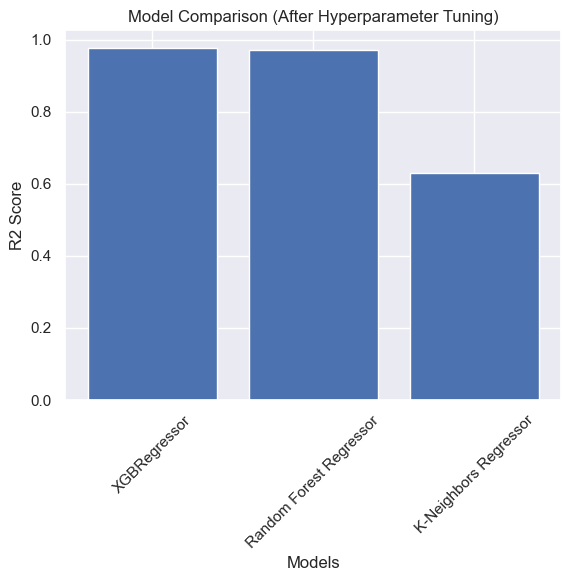

In [56]:
plt.figure()

plt.bar(results_df["Model Name"], results_df["R2_Score"])

plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (After Hyperparameter Tuning)")

plt.show()

## Final Model Selection

XGBoost is selected as the final model based on highest performance.

In [57]:
final_model = XGBRegressor(**model_param['XGBoost'])

In [58]:
final_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [59]:
y_pred = final_model.predict(X_test)

In [60]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print("Final MAE:", mae)
print("Final RMSE:", rmse)
print("Final R2 Score:", r2)

Final MAE: 2723.5833217446284
Final RMSE: 5338.336877988892
Final R2 Score: 0.9775184100548724


In [61]:
## Cross-validation is performed to ensure model generalization.
scores = cross_val_score(final_model, X, y, cv=5, scoring='r2')
print("Cross Validation R2:", scores.mean())

Cross Validation R2: 0.9816946973290724


## Salary Range Prediction

Separate models are trained to predict minimum and maximum salary values.

In [62]:
range_model_names = []
min_scores = []
max_scores = []

for name, model in models.items():
    
    model.fit(X_train_r, y_min_train)
    pred_min = model.predict(X_test_r)

    model.fit(X_train_r, y_max_train)
    pred_max = model.predict(X_test_r)

    r2_min = r2_score(y_min_test, pred_min)
    r2_max = r2_score(y_max_test, pred_max)

    range_model_names.append(name)
    min_scores.append(r2_min)
    max_scores.append(r2_max)

In [63]:
range_df = pd.DataFrame({
    "Model Name": range_model_names,
    "Min R2": min_scores,
    "Max R2": max_scores
})

range_df["Avg R2"] = (range_df["Min R2"] + range_df["Max R2"]) / 2
range_df = range_df.sort_values(by="Avg R2", ascending=False).reset_index(drop=True)

range_df

,Model Name,Min R2,Max R2,Avg R2
0,XGBRegressor,0.921974,0.977479,0.949727
1,Random Forest Regressor,0.919147,0.970552,0.944850
2,K-Neighbors Regressor,0.573891,0.641248,0.607570


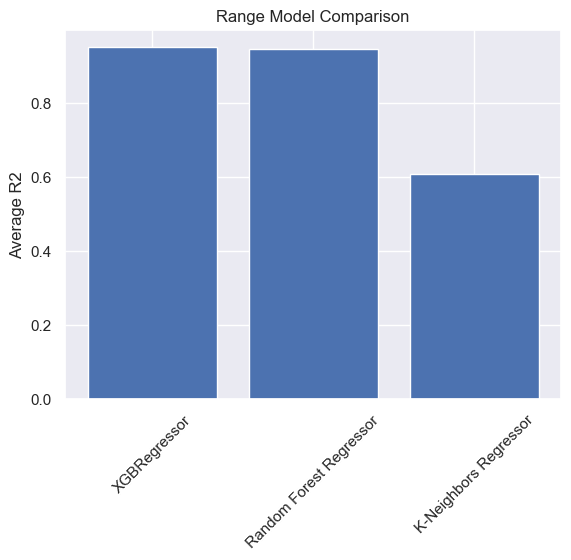

In [64]:
plt.figure()

plt.bar(range_df["Model Name"], range_df["Avg R2"])

plt.xticks(rotation=45)
plt.title("Range Model Comparison")
plt.ylabel("Average R2")

plt.show()

In [65]:
final_min_model = XGBRegressor(**model_param['XGBoost'])
final_max_model = XGBRegressor(**model_param['XGBoost'])

final_min_model.fit(X_train_r, y_min_train)
final_max_model.fit(X_train_r, y_max_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [66]:
pred_min = final_min_model.predict(X_test_r)
pred_max = final_max_model.predict(X_test_r)

print("Final MIN R2:", r2_score(y_min_test, pred_min))
print("Final MAX R2:", r2_score(y_max_test, pred_max))

Final MIN R2: 0.9219743774069594
Final MAX R2: 0.9774788743342824


In [67]:
range_pred_df = pd.DataFrame({
    "Actual Min Salary": y_min_test.values,
    "Predicted Min Salary": pred_min,
    "Actual Max Salary": y_max_test.values,
    "Predicted Max Salary": pred_max
})

range_pred_df.head()

,Actual Min Salary,Predicted Min Salary,Actual Max Salary,Predicted Max Salary
0,43728.0,43513.671875,52242.0,52075.582031
1,53057.0,55974.574219,61015.0,69815.242188
2,98470.0,98138.015625,133496.0,131898.937500
3,79620.0,81891.085938,91563.0,111663.242188
4,40866.0,40716.191406,40866.0,40556.238281


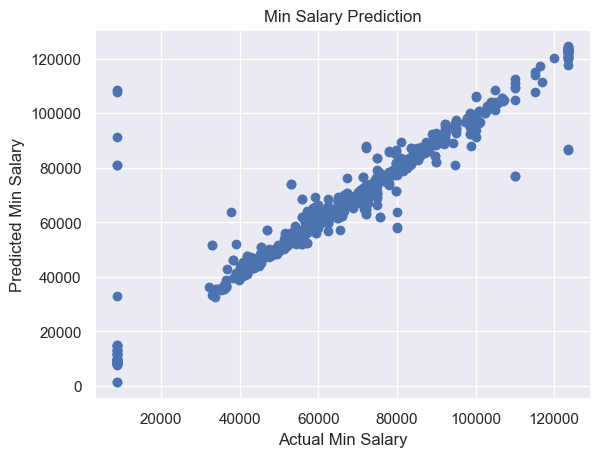

In [68]:
## SCATTER PLOT (MIN SALARY)
plt.figure()

plt.scatter(y_min_test, pred_min)

plt.xlabel("Actual Min Salary")
plt.ylabel("Predicted Min Salary")
plt.title("Min Salary Prediction")

plt.show()

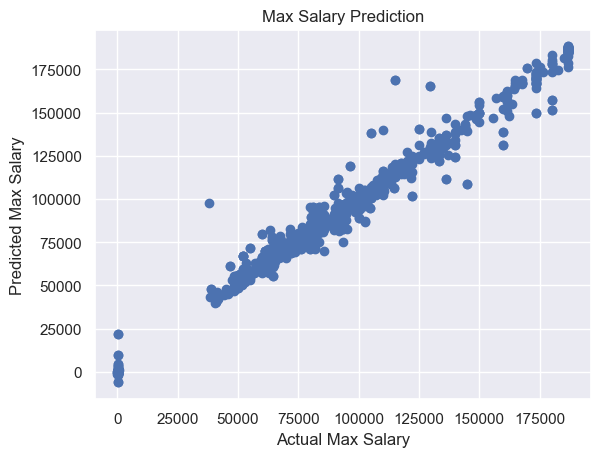

In [69]:
## SCATTER PLOT (MAX SALARY) 
plt.figure()

plt.scatter(y_max_test, pred_max)

plt.xlabel("Actual Max Salary")
plt.ylabel("Predicted Max Salary")
plt.title("Max Salary Prediction")

plt.show()

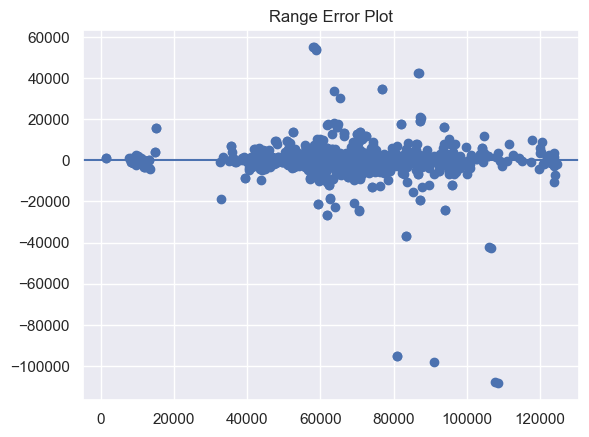

In [70]:
## RANGE ERROR PLOT
range_error = (pred_max - pred_min) - (y_max_test - y_min_test)

plt.figure()

plt.scatter(range_pred_df["Predicted Min Salary"], range_error)

plt.axhline(y=0)
plt.title("Range Error Plot")

plt.show()

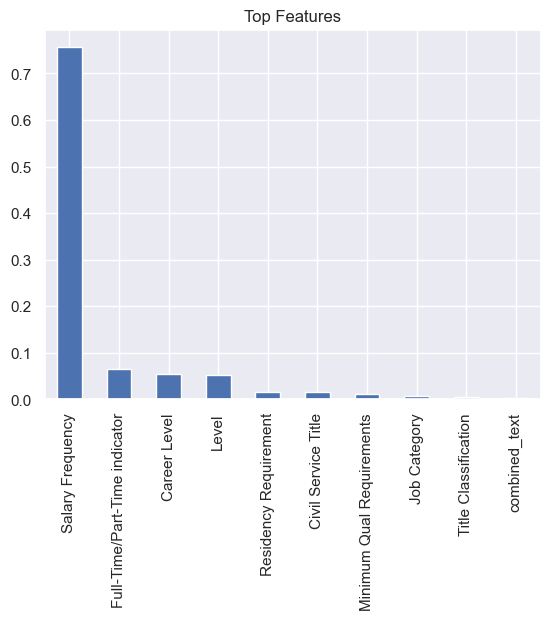

In [71]:
## FEATURE IMPORTANCE 
importance = pd.Series(final_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Features")
plt.show()

In [72]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test, check_additivity=False)

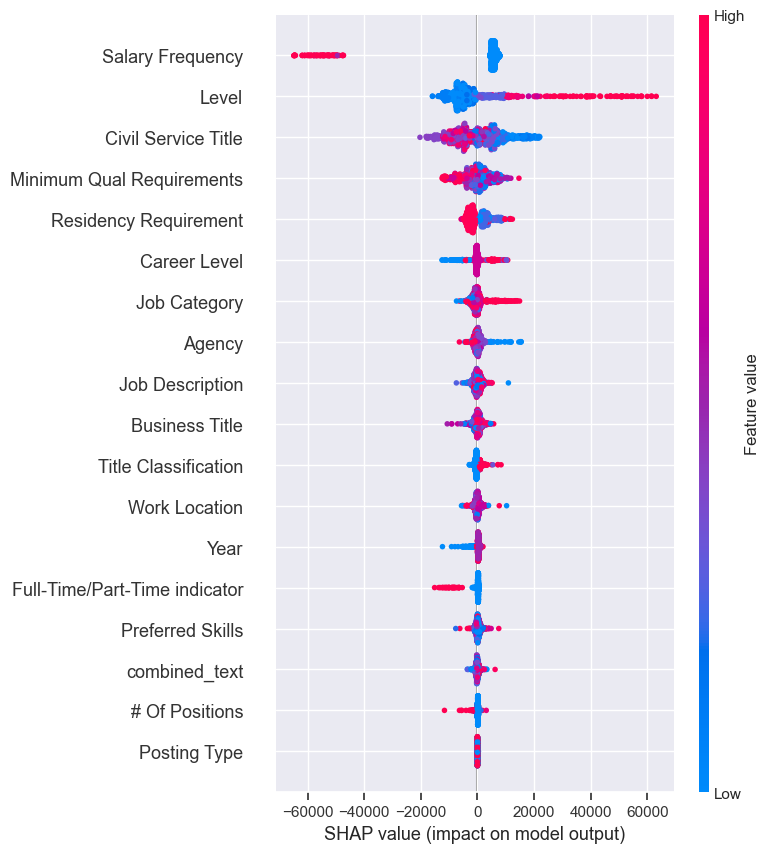

In [73]:
shap.summary_plot(shap_values, X_test)

In [74]:
## MODEL SAVED 
range_model = {
    "min_model": final_min_model,
    "max_model": final_max_model
}

joblib.dump(range_model, "salary_range_model.pkl")

['salary_range_model.pkl']

## Conclusion

In this project, we successfully developed a machine learning model to predict salary ranges (minimum and maximum) for job postings.

XGBoost performed the best among all models, achieving high accuracy in both minimum and maximum salary prediction.

The model demonstrates strong performance due to the presence of highly relevant features, and prediction results closely match actual values.

Overall, this solution can help organizations make better hiring decisions by providing accurate and transparent salary estimates.

##  Future Improvements

- Remove direct salary-related features to build a more generalized model  
- Apply advanced NLP techniques on job descriptions  
- Use deep learning models for better feature understanding  
- Deploy the model as a web application (Streamlit / Flask)  

## Key Takeaways

- Data preprocessing and feature engineering play a crucial role in model performance  
- Ensemble models like XGBoost and Random Forest provide superior results  
- Proper evaluation and visualization help in understanding model behavior  